# core

> bioMONAI core


In [2]:
#| default_exp core

In [3]:
#| hide
from nbdev.showdoc import *

In [4]:
#| export
from fastai.vision.all import *
from fastai.data.all import *
import torch.nn.functional as F
import torchvision

## Dataloaders

Get the ground truth images located in a folder called 'gt' and divided in labeled subfolders.

> These function are tailor-made for some test datasets, eventually they must be changed/adapted to more general cases


In [5]:
#| export
def get_gt(path, gt_file_name="avg50.png"): 
    def _fn(fn): return Path(path/"gt")/f"{parent_label(fn)}"/gt_file_name
    return _fn

def get_target(path, same_filename=True, target_file_prefix="target", signal_file_prefix="signal"):
    # Define a function to construct the target file name based on input parameters
    def construct_target_filename(file_name):
        # Split the file name based on the signal file prefix
        parts = file_name.split(signal_file_prefix)
        
        # Construct the target file name by inserting the target file prefix
        target_file_name = parts[0] + target_file_prefix + parts[1]
        
        return target_file_name
    
    # Define a function to generate the target file path based on the given file name
    def generate_target_path(file_name):
        # Extract the base file name
        base_filename = os.path.basename(file_name)
        
        # If same_filename is True, simply return the path joined with the base file name
        if same_filename:
            return Path(path) / base_filename
        
        # If same_filename is False, construct the target file name and return the path joined with it
        target_filename = construct_target_filename(base_filename)
        return Path(path) / target_filename
    
    # Return the appropriate function based on the value of same_filename
    return generate_target_path


In [6]:
print(get_target('train_folder', same_filename=False)('../signal/signal01.tif'))
print(get_target('train_folder')('../signal/image01.tif'))

train_folder/target01.tif
train_folder/image01.tif


Get as ground truth another noisy image randomly chosen in the same folder as the input image


In [6]:
#| export
from random import randint


In [7]:
#| export
def get_noisy_pair(fn):
    tmp = get_image_files(fn.parent, recurse=False)
    fn2 = tmp[randint(0,len(tmp)-1)]
    while fn2 == fn: fn2 = tmp[randint(0,len(tmp)-1)]
    return fn2

## Utils


In [8]:
#| export
# maybe this should be changed for fastai store_attr()
def attributesFromDict(d):
    self = d.pop('self')
    for n, v in d.items():
        setattr(self, n, v)

## Display 3D images

Function to display the 3D volume in axial, coronal or sagittal reconstruction. The display functions does not consider the spacing between pixels, so reconstructions may look unusual. 

In [9]:
#| export
# Utility function for determining figure bounds
def _fig_bounds(x):
    r = x//8
    return min(15, max(1,r))

In [10]:
#| export
def mosaic_image_3d(t: (np.ndarray, torch.Tensor),
                  axis: int = 0,
                  figsize: tuple = (15,15),
                  cmap: str = 'gray',
                  nrow: int = 10,
                  alpha = 1.,
                  return_grid = False,
                  add_to_existing = False,
                  **kwargs):
    '''
    Plots 2D slices of a 3D image alongside a prior specified axis.
    Args:
        t: a 3D numpy.ndarray or torch.Tensor
        axis: axis to split 3D array to 2D images
        figsize, cmap: passed to plt.imshow
        nrow: passed to torchvision.utils.make_grid
        return_grid: Whether the grid should be returned for further processing or if the plot should be displayed.
        add_to_existing: if set to true, no new figure will be created. Used for mask overlays
    '''
    if isinstance(t, np.ndarray): 
        t = tensor(t)
    
    if t.device.type == 'cuda': 
        t = t.cpu()
    
    if t.ndim < 3 or t.ndim > 4:
         raise TypeError('Object is not a rank 3 tensor but a rank {} tensor'.format(t.ndim ))
    if t.ndim == 4:
        t = t[0]

    if axis == 1: 
        t = np.transpose(t, (1, 0, 2))
    elif axis == 2: 
        t = np.transpose(t, (2, 0, 1))

    if t.min() < 0.:
        t = t - t.min()  # shift pixel values to positive range, otherwise the negative values will be clipped.

    t = t.unsqueeze(1)/t.max()  # rescale the images, makes for a nicer plot
    grid = torchvision.utils.make_grid(t, nrow=nrow)

    if return_grid:
        return grid

    if figsize is None:
        figsize = (_fig_bounds(t.shape[2]), _fig_bounds(t.shape[3]))

    if not add_to_existing:
        plt.figure(figsize=figsize)

    plt.imshow(grid[0,:,:], cmap=cmap, alpha=alpha)
    plt.axis('off')

In [11]:
#| export
def tiff2torch(file_path: str):
    '''
    Load tiff into pytorch tensor
    '''
    import tifffile as tiff
    
    img = np.array(tiff.imread(file_path))
    return torch.from_numpy(img)


In [12]:
#| export
@delegates(plt.Axes.imshow, keep=True, but=['shape', 'imlim'])
def show_images_grid(images, ax=None, ncols=10, figsize=None, title=None, spacing=0.02, max_slices=3, ctx=None, **kwargs):
    """
    Show a list of images arranged in a grid.

    Parameters:
    - images: list of images to display.
    - ncols (int): number of columns in the grid.
    - figsize (tuple, optional): figure size in inches.
    - titles (list, optional): list of titles corresponding to each image.
    - spacing (float, optional): spacing between subplots.
    - ctx: additional context passed to the `plt.Axes.imshow` function.
    - **kwargs: additional keyword arguments passed to `plt.Axes.imshow`.

    Returns:
    - axes: matplotlib axes containing the grid of images.
    """

    # Ensure images is a list
    images = list(images)

    # Compute number of rows needed based on number of columns and images
    n_images = len(images)
    nrows = (n_images - 1) // ncols + 1

    # Compute figure size if not provided
    if figsize is None:
        fig_width = ncols * (1 + spacing) - spacing
        fig_height = nrows * (1 + spacing) - spacing
        figsize = (fig_width, fig_height)

    ax = ifnone(ax,ctx)
    
    if ax is None:
        fig, ax = plt.subplots(nrows, ncols, figsize=figsize)
        fig.subplots_adjust(wspace=spacing, hspace=spacing) # Adjust spacing between subplots
    ax = np.atleast_2d(ax)

    # Turn off axes for all subplots
    for axis in ax.flatten():
        axis.axis('off')

    # Iterate over images and corresponding axes
    for i, (im, axis) in enumerate(zip(images, ax.flatten())):
        # Convert input to numpy array if necessary
        if isinstance(im, np.ndarray):
            im_to_show = im
        elif hasattrs(im, ('data', 'cpu', 'permute')):
            im_to_show = im.data.cpu()
            if im_to_show.ndim == 3:
                num_slices = im_to_show.shape[0]
                if num_slices < max_slices:
                    im_to_show = np.concatenate([im_to_show[i] for i in range(num_slices)], axis=1)
                else:
                    # showing middle slice
                    im_to_show = im_to_show[num_slices // 2]
            elif im_to_show.ndim == 4:
                im_to_show = im_to_show[0]
        else:
            im_to_show = array(im)

        # Display image on current axes
        axis.imshow(im_to_show, **kwargs)
        if title is not None and i < len(title):
            axis.set_title(title[i])

    # Hide unused axes
    for axis in ax.flatten()[n_images:]:
        axis.set_visible(False)

    return ax

torch.Size([96, 512, 512])


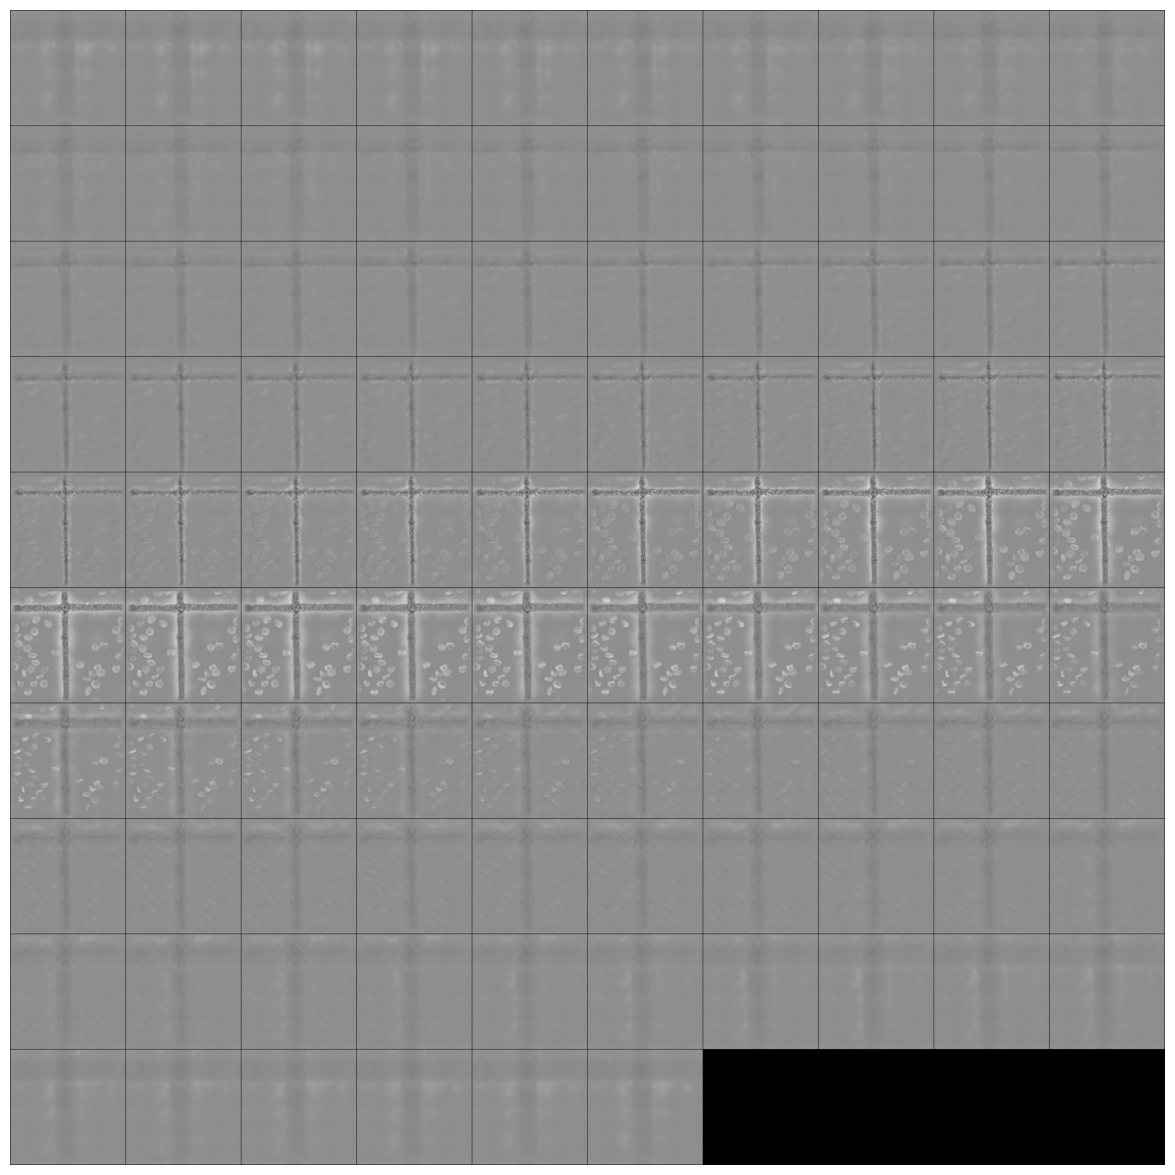

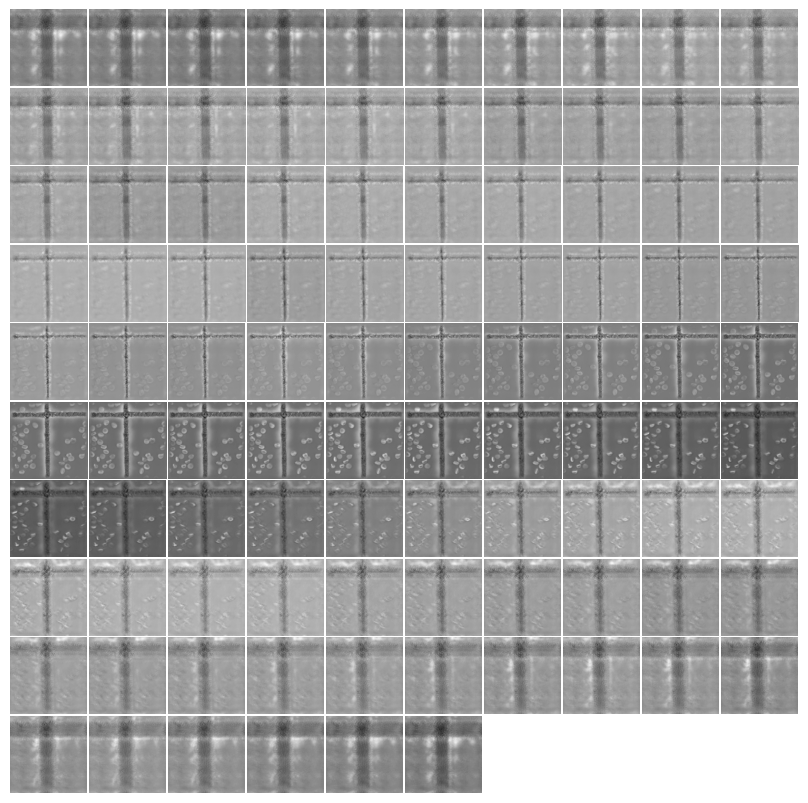

In [14]:
file_path = '../../bioMONAI-main_0/_data/Babesia/RI/O11_RI_frame01.tiff' #'../_data/Babesia/RI/O11_RI_frame01.tiff'
img_tensor = tiff2torch(file_path)

print(img_tensor.shape)

mosaic_image_3d(img_tensor, figsize=None)

show_images_grid(img_tensor, cmap='gray');

# Other functions

features to be implemented

In [15]:
import multipagetiff as mtif


In [16]:
# Load the stack and define the resolution and the units
s = mtif.read_stack(file_path, dx=100, dz=500, units='nm')
print(s)

Multi-Page Stack of 96 pages. (dx=dy=100nm, dz=500nm, crop=[0, 512, 0, 512]], page limits=[0, 96])


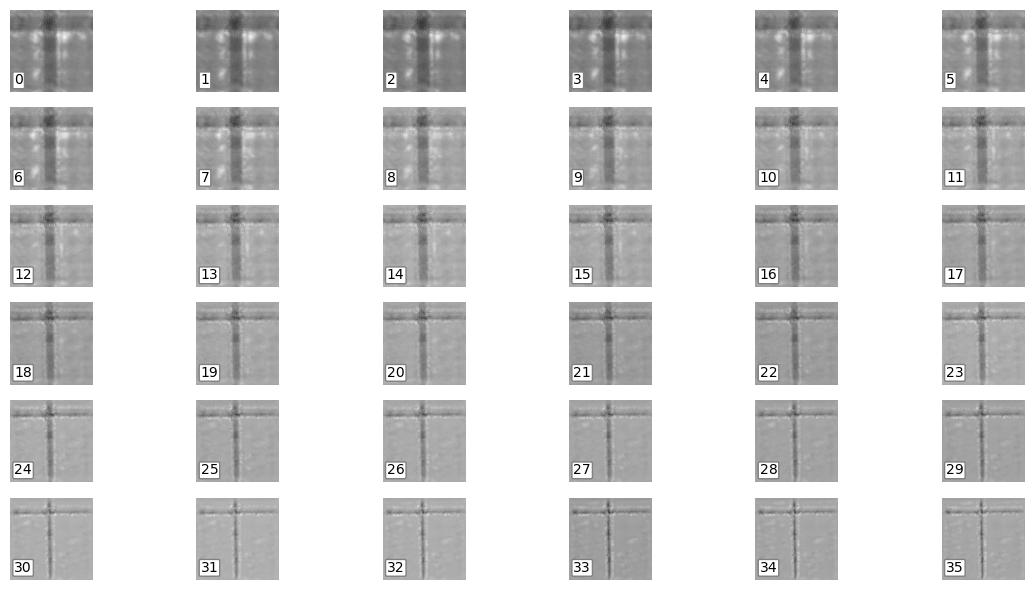

In [17]:
# display the stack
plt.figure(figsize=(12,6))
mtif.plot_pages(s, cmap='gray')

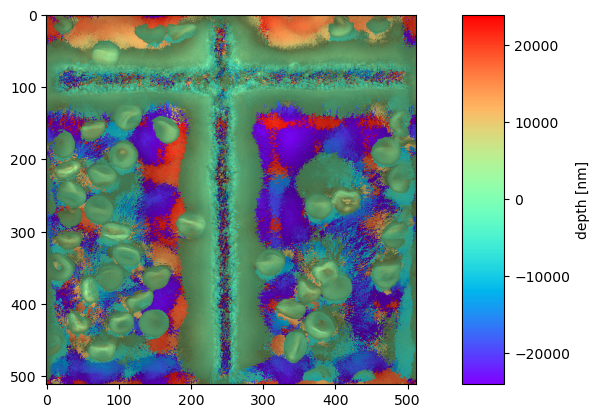

In [18]:
mtif.set_cmap(plt.cm.rainbow)
mtif.plot_flatten(s)

In [19]:
s2 = s.pages
print('type: ', type(s2), '\nshape: ', s2.shape)

type:  <class 'numpy.ndarray'> 
shape:  (96, 512, 512)


In [1]:
#| hide
import nbdev; nbdev.nbdev_export()